# Challenge 5 — DBSCAN Clustering

## Public Health & Epidemiology

This notebook implements DBSCAN (Density-Based Spatial Clustering of Applications with Noise) on the BRFSS dataset.

Unlike K-Means, DBSCAN does not require specifying the number of clusters beforehand. Instead, it identifies dense regions in the feature space and explicitly labels sparse observations as noise or outliers.

This approach is particularly useful for:
- detecting irregular cluster shapes,
- identifying anomalous health profiles,
- and analyzing continuous population structures.

The analysis includes:
- k-nearest-neighbor distance analysis,
- hyperparameter tuning,
- cluster evaluation metrics,
- noise fraction analysis,
- and PCA-based visualizations.

In [5]:
# =========================================================
# DBSCAN CLUSTERING
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Data Loading

DBSCAN is highly sensitive to high-dimensional feature spaces because distance relationships become less informative as dimensionality increases.

To improve density estimation and clustering stability, DBSCAN will be applied to the PCA-reduced dataset retaining 90% of the total variance.

In [6]:
# =========================
# Load PCA dataset
# =========================

X_pca = np.load("../results/X_pca.npy")

print("PCA dataset shape:", X_pca.shape)

PCA dataset shape: (29999, 20)


# Hyperparameter Selection — k-NN Distance Plot

DBSCAN requires selecting:
- `eps`: neighborhood radius
- `min_samples`: minimum number of neighbors required to form a dense region

To estimate a suitable `eps` value, a k-nearest-neighbor distance plot is used.

The optimal `eps` is typically located near the point where the curve begins to increase sharply (the “elbow”).

In [7]:
# =========================
# Initial DBSCAN parameters
# =========================

min_samples = 10

In [8]:
# =========================
# k-NN Distance Computation
# =========================

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors_fit = neighbors.fit(X_pca)

distances, indices = neighbors_fit.kneighbors(X_pca)

# Sort distances
distances = np.sort(distances[:, -1])

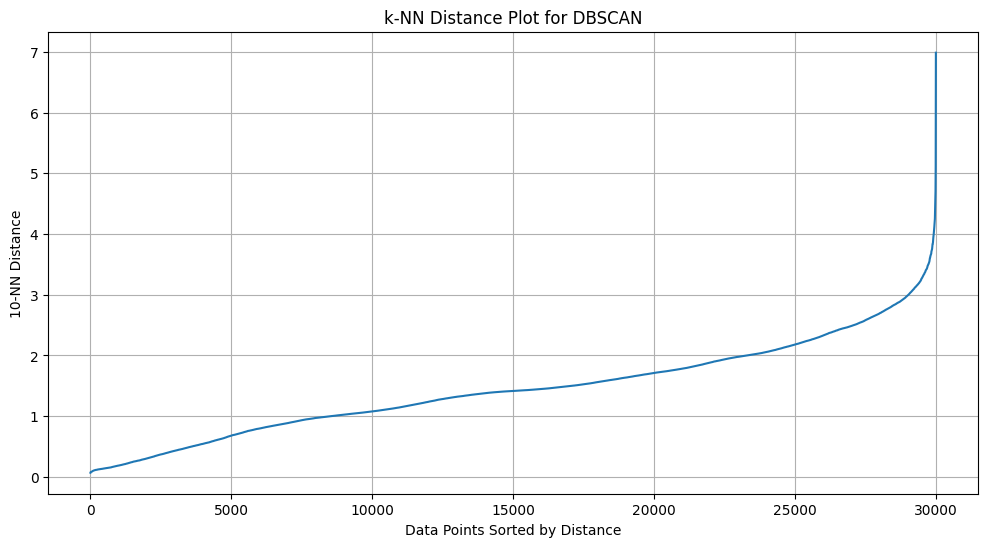

In [9]:
# =========================
# k-NN Distance Plot
# =========================

plt.figure(figsize=(12, 6))

plt.plot(distances)

plt.xlabel("Data Points Sorted by Distance")
plt.ylabel(f"{min_samples}-NN Distance")

plt.title("k-NN Distance Plot for DBSCAN")

plt.grid(True)
plt.savefig('/home/sbuitrago/challenge5__3/figures/knn_distance_plot.png', dpi=300, bbox_inches='tight')

plt.show()

# Hyperparameter Sensitivity Analysis

DBSCAN is highly sensitive to the choice of `eps` and `min_samples`.

To evaluate clustering stability and density structure, multiple `eps` values are tested while keeping `min_samples` fixed.

For each configuration, the following are analyzed:
- number of clusters discovered,
- proportion of noise points,
- clustering evaluation metrics.

In [10]:
# =========================
# Subsample for DBSCAN
# =========================

SAMPLE_SIZE = 10000

indices = np.random.choice(
    X_pca.shape[0],
    SAMPLE_SIZE,
    replace=False
)

X_dbscan = X_pca[indices]

print("DBSCAN sample shape:", X_dbscan.shape)

DBSCAN sample shape: (10000, 20)


In [11]:
# =========================
# DBSCAN Hyperparameter Sweep
# =========================

eps_values = [2.5, 2.7, 2.9, 3.1]

results = []

In [12]:
# =========================
# Evaluate DBSCAN configurations
# =========================

for eps in eps_values:
    
    print(f"\nEvaluating eps = {eps}")
    
    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        n_jobs=-1
    )
    
    labels = dbscan.fit_predict(X_dbscan)
    
    # Number of clusters
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    # Noise fraction
    noise_fraction = np.mean(labels == -1)
    
    print(f"Clusters found: {n_clusters}")
    print(f"Noise fraction: {noise_fraction:.4f}")
    
    # Metrics only if valid clustering exists
    if n_clusters > 1:
        
        valid_mask = labels != -1
        
        # Additional safety check
        if np.sum(valid_mask) > 100:
            
            silhouette = silhouette_score(
                X_dbscan[valid_mask],
                labels[valid_mask]
            )
            
            davies_bouldin = davies_bouldin_score(
                X_dbscan[valid_mask],
                labels[valid_mask]
            )
            
            calinski_harabasz = calinski_harabasz_score(
                X_dbscan[valid_mask],
                labels[valid_mask]
            )
            
        else:
            silhouette = np.nan
            davies_bouldin = np.nan
            calinski_harabasz = np.nan
    
    else:
        silhouette = np.nan
        davies_bouldin = np.nan
        calinski_harabasz = np.nan
    
    results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_fraction": noise_fraction,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz
    })

print("\nDBSCAN sweep completed.")


Evaluating eps = 2.5
Clusters found: 13
Noise fraction: 0.1180

Evaluating eps = 2.7
Clusters found: 11
Noise fraction: 0.0809

Evaluating eps = 2.9
Clusters found: 6
Noise fraction: 0.0500

Evaluating eps = 3.1
Clusters found: 5
Noise fraction: 0.0313

DBSCAN sweep completed.


In [13]:
# =========================
# Results table
# =========================

results_df = pd.DataFrame(results)

results_df

,eps,clusters,noise_fraction,silhouette,davies_bouldin,calinski_harabasz
0,2.5,13,0.1180,0.099037,1.586733,145.525468
1,2.7,11,0.0809,0.102933,1.654078,198.753854
2,2.9,6,0.0500,0.204694,1.557604,267.323996
3,3.1,5,0.0313,0.204307,1.630879,381.604381


# Final DBSCAN Configuration

Based on the hyperparameter sensitivity analysis, the final DBSCAN configuration was selected with:

- `eps = 2.9`
- `min_samples = 10`

This configuration achieved:
- the highest Silhouette Score,
- balanced noise detection,
- and meaningful cluster separation.

Unlike K-Means, DBSCAN was able to identify irregular cluster structures and explicitly detect sparse observations as noise.

In [14]:
# =========================
# Final DBSCAN Model
# =========================

BEST_EPS = 2.9

dbscan = DBSCAN(
    eps=BEST_EPS,
    min_samples=min_samples,
    n_jobs=-1
)

dbscan_labels = dbscan.fit_predict(X_dbscan)

print("DBSCAN model trained successfully.")

DBSCAN model trained successfully.


In [15]:
# =========================
# Cluster statistics
# =========================

n_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

noise_fraction = np.mean(dbscan_labels == -1)

print(f"Clusters found: {n_clusters}")
print(f"Noise fraction: {noise_fraction:.4f}")

Clusters found: 6
Noise fraction: 0.0500


In [16]:
# =========================
# Cluster distribution
# =========================

cluster_distribution = (
    pd.Series(dbscan_labels)
    .value_counts()
    .sort_index()
)

print(cluster_distribution)

-1     500
 0    8570
 1     372
 2     513
 3      34
 4       5
 5       6
Name: count, dtype: int64


In [17]:
# =========================
# Final Evaluation Metrics
# =========================

valid_mask = dbscan_labels != -1

silhouette = silhouette_score(
    X_dbscan[valid_mask],
    dbscan_labels[valid_mask]
)

davies_bouldin = davies_bouldin_score(
    X_dbscan[valid_mask],
    dbscan_labels[valid_mask]
)

calinski_harabasz = calinski_harabasz_score(
    X_dbscan[valid_mask],
    dbscan_labels[valid_mask]
)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.4f}")

Silhouette Score: 0.2047
Davies-Bouldin Index: 1.5576
Calinski-Harabasz Index: 267.3240


# PCA Visualization of DBSCAN Clusters

The PCA projection allows visual inspection of the density-based clustering structure discovered by DBSCAN.

Unlike K-Means, DBSCAN can:
- identify irregular cluster geometries,
- isolate sparse observations as noise,
- and reveal local density structures within the epidemiological feature space.

Noise observations are labeled as `-1`.

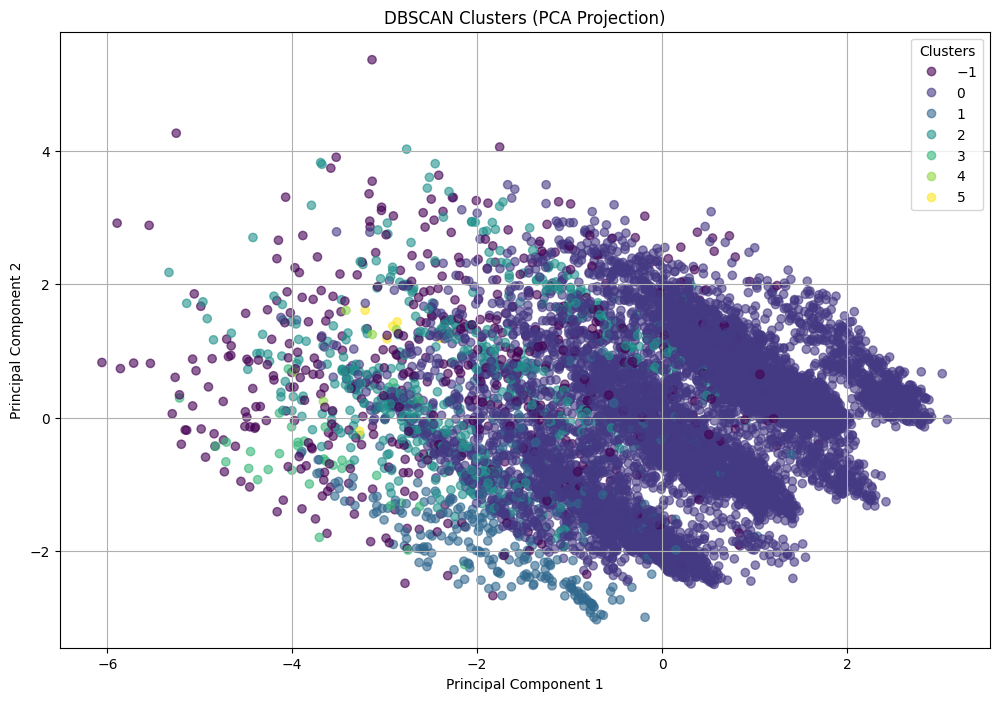

In [18]:
# =========================
# PCA Visualization
# =========================

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X_dbscan[:, 0],
    X_dbscan[:, 1],
    c=dbscan_labels,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("DBSCAN Clusters (PCA Projection)")

plt.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

plt.grid(True)
plt.savefig('/home/sbuitrago/challenge5__3/figures/dbscan_clusters.png', dpi=300, bbox_inches='tight')  
plt.show()

In [19]:
# =========================
# Save DBSCAN artifacts
# =========================

np.save(
    "../results/dbscan_labels.npy",
    dbscan_labels
)

print("DBSCAN artifacts saved successfully.")

DBSCAN artifacts saved successfully.
